# Сравнение обратного распространения ошибки для разных функций потерь

Проект построен по статье `project_base.pdf` (*Loss Functions and Metrics in Deep Learning*, Terven et al., 2024): в ней loss-функции рассматриваются как часть обучения модели, а метрики - как инструмент оценки после обучения.

Цель проекта: на одинаковых моделях и данных сравнить, как разные функции потерь влияют на backpropagation:

- величину градиента по логиту и параметрам;
- скорость сходимости;
- итоговые метрики;
- устойчивость к выбросам;
- форму границы решения/аппроксимации.

Главный акцент - сравнение MSE и Cross-Entropy. Дополнительно рассматриваются Hinge и Focal для классификации, MAE, Huber и Log-Cosh для регрессии.

## Краткая теория

Обратное распространение ошибки применяет цепное правило:

$$
\frac{\partial L}{\partial w} =
\frac{\partial L}{\partial \hat y}
\frac{\partial \hat y}{\partial z}
\frac{\partial z}{\partial w},
$$

где $L$ - функция потерь, $\hat y$ - предсказание, $z$ - логит/выход линейного слоя, $w$ - параметры модели.

Именно loss-функция задаёт первый множитель градиента. Поэтому при одинаковой архитектуре разные loss-функции могут давать разные по масштабу и направлению обновления весов.

Для бинарной классификации с вероятностью $p=\sigma(z)$:

**Binary Cross-Entropy**

$$
L_{BCE}= -y\log p -(1-y)\log(1-p), \qquad
\frac{\partial L}{\partial z}=p-y
$$

**MSE по вероятности**

$$
L_{MSE}=(p-y)^2, \qquad
\frac{\partial L}{\partial z}=2(p-y)p(1-p)
$$

Ключевое отличие: у MSE появляется дополнительный множитель $p(1-p)$. Если модель сильно ошибается и логит насыщает sigmoid, градиент MSE становится маленьким. У Cross-Entropy градиент остаётся заметным: $p-y$.

In [1]:
import math
import os
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 1. Аналитическое сравнение градиента по логиту

Сначала сравним не обучение модели, а сам backprop-сигнал $\partial L / \partial z$ для одного объекта класса `1`.

Это показывает, какой сигнал loss передаёт назад в сеть ещё до учёта архитектуры.

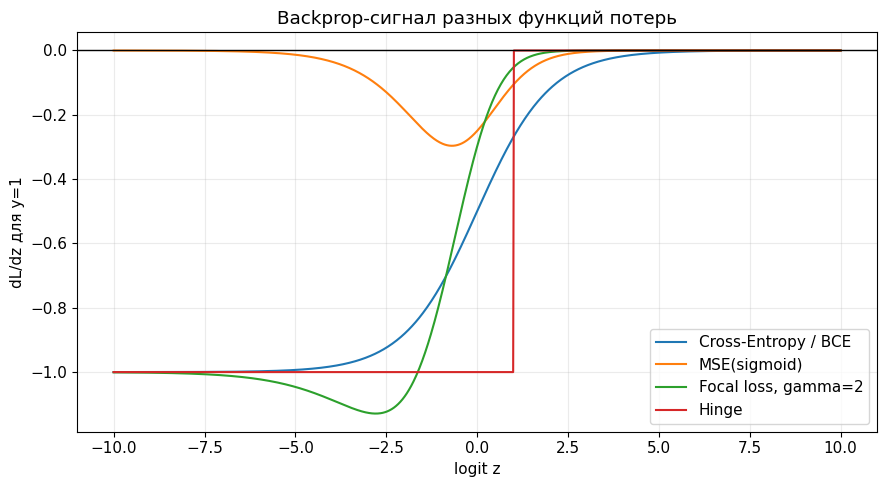

In [2]:
z = torch.linspace(-10, 10, 1000)
p = torch.sigmoid(z)
y = torch.ones_like(p)

grad_bce = p - y
grad_mse = 2 * (p - y) * p * (1 - p)
gamma = 2.0
# Focal loss for y=1: L=-(1-p)^gamma*log(p)
# derivative computed by autograd for clarity
z_focal = z.clone().detach().requires_grad_(True)
p_focal = torch.sigmoid(z_focal)
loss_focal = -((1 - p_focal) ** gamma) * torch.log(p_focal.clamp_min(1e-8))
grad_focal = torch.autograd.grad(loss_focal.sum(), z_focal)[0].detach()
grad_hinge = torch.where(z < 1, -torch.ones_like(z), torch.zeros_like(z))  # y=1, L=max(0, 1-z)

plt.figure(figsize=(9, 5))
plt.plot(z, grad_bce, label="Cross-Entropy / BCE")
plt.plot(z, grad_mse, label="MSE(sigmoid)")
plt.plot(z, grad_focal, label="Focal loss, gamma=2")
plt.plot(z, grad_hinge, label="Hinge")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("logit z")
plt.ylabel("dL/dz для y=1")
plt.title("Backprop-сигнал разных функций потерь")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/gradient_by_logit.png", dpi=160)
plt.show()

Вывод по графику:

- при сильной ошибке для класса `1` логит отрицательный, $p$ близко к 0;
- Cross-Entropy даёт градиент примерно `-1`, то есть сильный сигнал для исправления ошибки;
- MSE даёт почти нулевой градиент из-за множителя $p(1-p)$;
- Hinge даёт постоянный градиент до выполнения margin;
- Focal усиливает вклад сложных примеров и подавляет лёгкие.

## 2. Эксперимент классификации

Задача: бинарная классификация `make_moons`. Архитектура, начальная инициализация, train/test split и число эпох одинаковые для всех loss-функций.

Сравниваем:

- `Cross-Entropy / BCEWithLogits`;
- `MSE(sigmoid)` - MSE между вероятностью и меткой;
- `Hinge` - margin-based loss по логиту;
- `Focal` - модификация BCE с фокусом на сложных примерах.

In [3]:
X, y = make_moons(n_samples=1200, noise=0.25, random_state=SEED)
X = StandardScaler().fit_transform(X).astype(np.float32)
y = y.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

X_train_t = torch.tensor(X_train, device=device)
y_train_t = torch.tensor(y_train, device=device)
X_test_t = torch.tensor(X_test, device=device)
y_test_t = torch.tensor(y_test, device=device)


class BinaryMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)


def focal_bce_with_logits(logits, targets, gamma=2.0, alpha=0.25):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    p = torch.sigmoid(logits)
    p_t = targets * p + (1 - targets) * (1 - p)
    alpha_t = targets * alpha + (1 - targets) * (1 - alpha)
    return (alpha_t * (1 - p_t) ** gamma * bce).mean()


def classification_loss(name, logits, targets):
    if name == "Cross-Entropy (BCE)":
        return F.binary_cross_entropy_with_logits(logits, targets)
    if name == "MSE(sigmoid)":
        return F.mse_loss(torch.sigmoid(logits), targets)
    if name == "Hinge":
        signed_targets = targets * 2 - 1
        return torch.clamp(1 - signed_targets * logits, min=0).mean()
    if name == "Focal":
        return focal_bce_with_logits(logits, targets)
    raise ValueError(name)


def evaluate_classifier(model):
    model.eval()
    with torch.no_grad():
        logits = model(X_test_t)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
    pred = (probs >= 0.5).astype(int)
    true = y_test.ravel().astype(int)
    return {
        "accuracy": accuracy_score(true, pred),
        "f1": f1_score(true, pred),
        "brier_mse": mean_squared_error(true, probs),
    }


def train_classifier(loss_name, epochs=350, lr=0.05):
    torch.manual_seed(SEED)
    model = BinaryMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_t)
        loss = classification_loss(loss_name, logits, y_train_t)
        loss.backward()
        grad_norm = model.net[0].weight.grad.detach().norm().item()
        optimizer.step()

        if epoch % 5 == 0 or epoch == epochs - 1:
            metrics = evaluate_classifier(model)
            history.append({
                "epoch": epoch,
                "loss": loss.item(),
                "grad_norm_first_layer": grad_norm,
                **metrics,
            })
    return model, pd.DataFrame(history)


classification_results = {}
classification_histories = {}

for loss_name in ["Cross-Entropy (BCE)", "MSE(sigmoid)", "Hinge", "Focal"]:
    model, hist = train_classifier(loss_name)
    classification_results[loss_name] = evaluate_classifier(model)
    classification_histories[loss_name] = hist

pd.DataFrame(classification_results).T.sort_values("accuracy", ascending=False)

,accuracy,f1,brier_mse
Cross-Entropy (BCE),0.944444,0.943503,0.042632
Hinge,0.941667,0.940845,0.057515
MSE(sigmoid),0.891667,0.888889,0.088968
Focal,0.827778,0.802548,0.138463


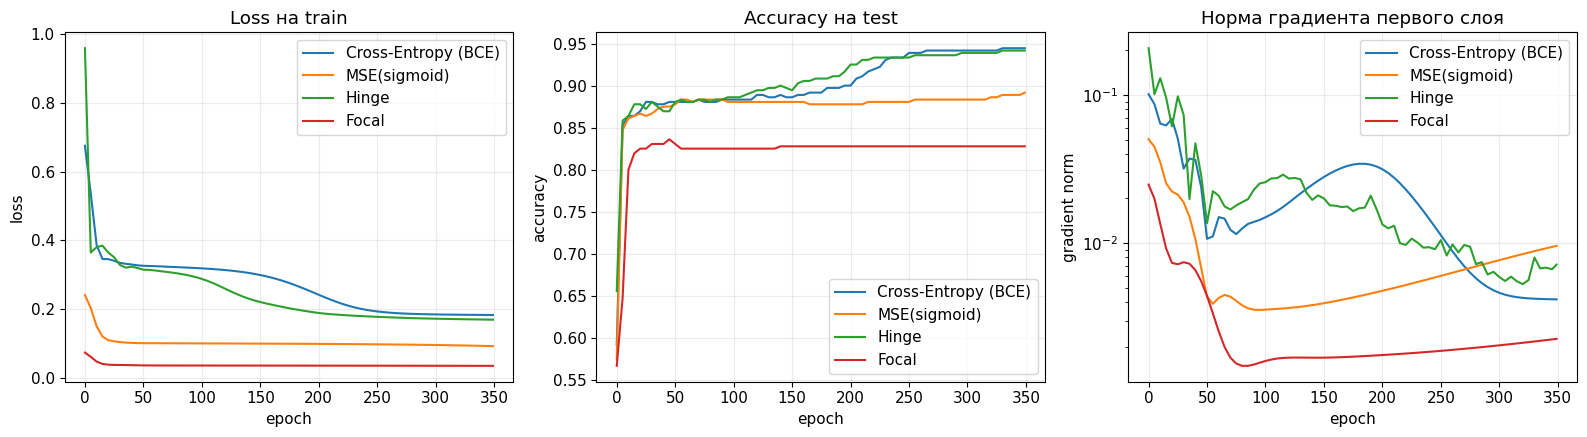

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for loss_name, hist in classification_histories.items():
    axes[0].plot(hist["epoch"], hist["loss"], label=loss_name)
    axes[1].plot(hist["epoch"], hist["accuracy"], label=loss_name)
    axes[2].plot(hist["epoch"], hist["grad_norm_first_layer"], label=loss_name)

axes[0].set_title("Loss на train")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[1].set_title("Accuracy на test")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[2].set_title("Норма градиента первого слоя")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("gradient norm")
axes[2].set_yscale("log")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/classification_training_curves.png", dpi=160)
plt.show()

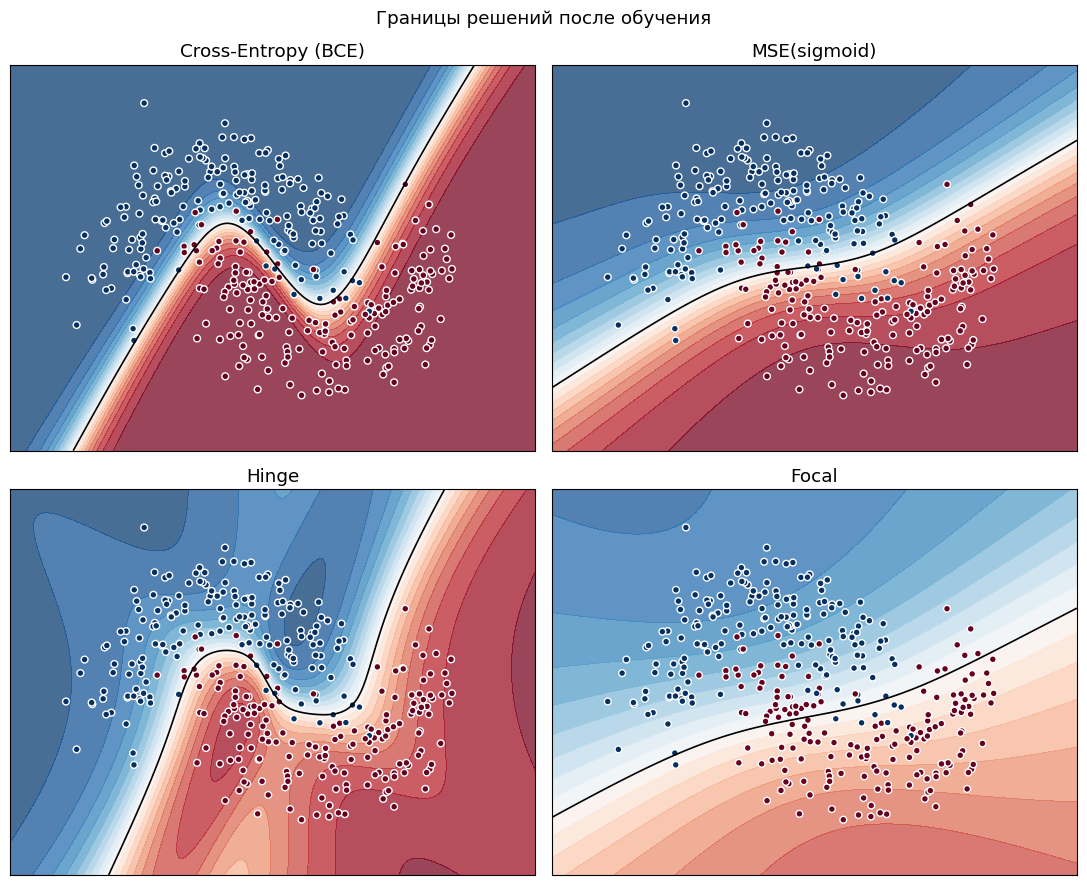

In [5]:
def plot_decision_boundaries(models):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_t = torch.tensor(grid, device=device)

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    axes = axes.ravel()

    for ax, (loss_name, model) in zip(axes, models.items()):
        model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(model(grid_t)).cpu().numpy().reshape(xx.shape)
        ax.contourf(xx, yy, probs, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.75)
        ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=1.2)
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test.ravel(), cmap="RdBu_r", edgecolor="white", s=24)
        ax.set_title(loss_name)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle("Границы решений после обучения")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/classification_decision_boundaries.png", dpi=160)
    plt.show()


trained_models = {name: train_classifier(name)[0] for name in classification_histories.keys()}
plot_decision_boundaries(trained_models)

### Интерпретация классификации

Для классификации Cross-Entropy обычно оптимизируется лучше, чем MSE по вероятности, потому что её градиент по логиту равен $p-y$ и не получает дополнительного подавления от производной sigmoid. Поэтому CE быстрее исправляет уверенные неправильные ответы.

MSE остаётся допустимой метрикой качества вероятностей, например как Brier score, но как loss для классификации она часто проигрывает CE по скорости и устойчивости обучения.

Hinge хорошо работает как margin-loss: он не стремится к калиброванным вероятностям, а заставляет объекты оказаться по правильную сторону границы с запасом. Focal полезна при дисбалансе классов или большом числе лёгких примеров: она уменьшает вклад уже правильно классифицированных объектов.

## 3. Эксперимент регрессии

Теперь сравним loss-функции на регрессии с выбросами. Данные: зашумлённая синусоида, часть точек испорчена большими выбросами.

Сравниваем:

- `MSE` - сильно штрафует большие ошибки;
- `MAE` - устойчивее к выбросам, но градиент менее гладкий;
- `Huber` - MSE около нуля и MAE на больших ошибках;
- `Log-Cosh` - гладкая робастная альтернатива Huber.

In [6]:
n = 360
rng = np.random.default_rng(SEED)
X_reg = rng.uniform(-3, 3, size=(n, 1)).astype(np.float32)
y_clean = np.sin(2.2 * X_reg) + 0.25 * X_reg
y_reg = y_clean + rng.normal(0, 0.15, size=(n, 1)).astype(np.float32)

outlier_idx = rng.choice(n, size=int(0.12 * n), replace=False)
y_reg[outlier_idx] += rng.normal(0, 2.2, size=(len(outlier_idx), 1)).astype(np.float32)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=SEED
)

Xr_train_t = torch.tensor(Xr_train, device=device)
yr_train_t = torch.tensor(yr_train, device=device)
Xr_test_t = torch.tensor(Xr_test, device=device)
yr_test_t = torch.tensor(yr_test, device=device)


class RegressionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


def log_cosh_loss(pred, target):
    error = pred - target
    return torch.log(torch.cosh(error + 1e-12)).mean()


def regression_loss(name, pred, target):
    if name == "MSE":
        return F.mse_loss(pred, target)
    if name == "MAE":
        return F.l1_loss(pred, target)
    if name == "Huber":
        return F.huber_loss(pred, target, delta=0.5)
    if name == "Log-Cosh":
        return log_cosh_loss(pred, target)
    raise ValueError(name)


def evaluate_regressor(model):
    model.eval()
    with torch.no_grad():
        pred = model(Xr_test_t).cpu().numpy()
    return {
        "rmse": math.sqrt(mean_squared_error(yr_test, pred)),
        "mae": mean_absolute_error(yr_test, pred),
        "r2": r2_score(yr_test, pred),
    }


def train_regressor(loss_name, epochs=700, lr=0.01):
    torch.manual_seed(SEED)
    model = RegressionMLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(Xr_train_t)
        loss = regression_loss(loss_name, pred, yr_train_t)
        loss.backward()
        grad_norm = model.net[0].weight.grad.detach().norm().item()
        optimizer.step()

        if epoch % 10 == 0 or epoch == epochs - 1:
            history.append({
                "epoch": epoch,
                "loss": loss.item(),
                "grad_norm_first_layer": grad_norm,
                **evaluate_regressor(model),
            })
    return model, pd.DataFrame(history)


regression_models = {}
regression_histories = {}
regression_results = {}

for loss_name in ["MSE", "MAE", "Huber", "Log-Cosh"]:
    model, hist = train_regressor(loss_name)
    regression_models[loss_name] = model
    regression_histories[loss_name] = hist
    regression_results[loss_name] = evaluate_regressor(model)

pd.DataFrame(regression_results).T.sort_values("mae")

,rmse,mae,r2
Huber,0.844997,0.330302,0.262808
MAE,0.849224,0.331512,0.255414
Log-Cosh,0.843718,0.341791,0.265038
MSE,0.849618,0.396904,0.254724


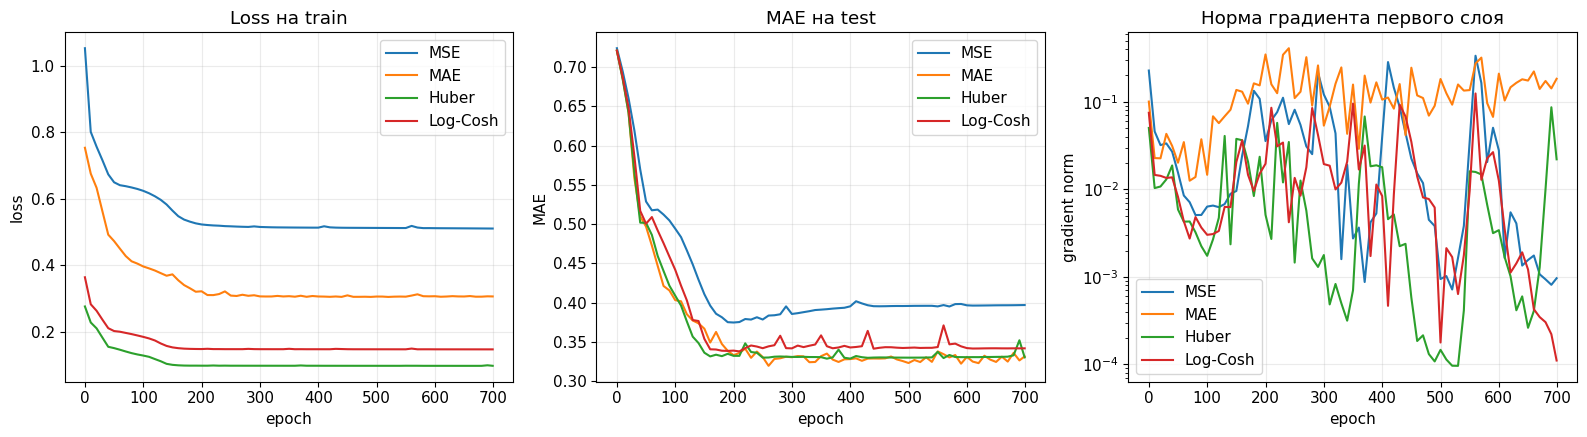

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for loss_name, hist in regression_histories.items():
    axes[0].plot(hist["epoch"], hist["loss"], label=loss_name)
    axes[1].plot(hist["epoch"], hist["mae"], label=loss_name)
    axes[2].plot(hist["epoch"], hist["grad_norm_first_layer"], label=loss_name)

axes[0].set_title("Loss на train")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[1].set_title("MAE на test")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("MAE")
axes[2].set_title("Норма градиента первого слоя")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("gradient norm")
axes[2].set_yscale("log")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/regression_training_curves.png", dpi=160)
plt.show()

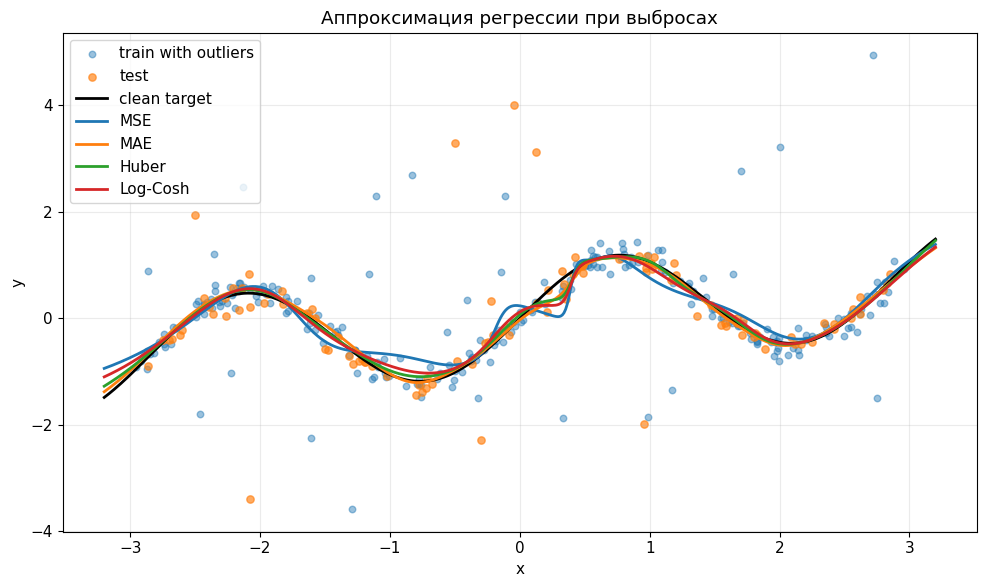

In [8]:
x_plot = np.linspace(-3.2, 3.2, 500).reshape(-1, 1).astype(np.float32)
x_plot_t = torch.tensor(x_plot, device=device)

plt.figure(figsize=(10, 6))
plt.scatter(Xr_train, yr_train, s=22, alpha=0.45, label="train with outliers")
plt.scatter(Xr_test, yr_test, s=28, alpha=0.65, label="test")
plt.plot(x_plot, np.sin(2.2 * x_plot) + 0.25 * x_plot, color="black", linewidth=2, label="clean target")

for loss_name, model in regression_models.items():
    model.eval()
    with torch.no_grad():
        pred = model(x_plot_t).cpu().numpy()
    plt.plot(x_plot, pred, linewidth=2, label=loss_name)

plt.title("Аппроксимация регрессии при выбросах")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/regression_predictions.png", dpi=160)
plt.show()

### Интерпретация регрессии

MSE даёт градиент, пропорциональный ошибке: чем дальше точка от предсказания, тем сильнее она двигает параметры. Это ускоряет обучение на чистых данных, но при выбросах модель может начать подстраиваться под неправильные точки.

MAE ограничивает влияние больших ошибок: градиент по предсказанию равен знаку ошибки. Поэтому она робастнее, но около минимума менее гладкая.

Huber и Log-Cosh являются компромиссами: они ведут себя как MSE для малых ошибок и как MAE для больших. В задачах с выбросами такие функции часто дают более стабильную аппроксимацию.

## 4. Сводные таблицы

In [9]:
classification_table = pd.DataFrame(classification_results).T
classification_table = classification_table.sort_values(["accuracy", "f1"], ascending=False)
classification_table

,accuracy,f1,brier_mse
Cross-Entropy (BCE),0.944444,0.943503,0.042632
Hinge,0.941667,0.940845,0.057515
MSE(sigmoid),0.891667,0.888889,0.088968
Focal,0.827778,0.802548,0.138463


In [10]:
regression_table = pd.DataFrame(regression_results).T
regression_table = regression_table.sort_values("mae")
regression_table

,rmse,mae,r2
Huber,0.844997,0.330302,0.262808
MAE,0.849224,0.331512,0.255414
Log-Cosh,0.843718,0.341791,0.265038
MSE,0.849618,0.396904,0.254724


## Итоговые выводы

1. Для классификации Cross-Entropy лучше согласована с sigmoid/softmax-выходом, чем MSE: её градиент по логиту не исчезает так быстро на уверенных ошибках.

2. MSE можно использовать как метрику качества вероятностных прогнозов, но как training loss для классификации она часто обучается медленнее и хуже исправляет насыщенные неправильные предсказания.

3. Hinge оптимизирует разделяющую границу с margin, но не калибрует вероятности. Поэтому её удобно сравнивать по accuracy/F1, но не по вероятностным метрикам.

4. Focal loss полезна, когда много лёгких примеров или есть дисбаланс классов: она уменьшает вклад объектов, которые модель уже уверенно классифицирует правильно.

5. Для регрессии MSE чувствительна к выбросам, потому что большие ошибки дают большие градиенты. MAE, Huber и Log-Cosh уменьшают влияние выбросов, поэтому могут давать более устойчивую модель.

6. Выбор loss-функции напрямую меняет backpropagation: даже при одинаковой сети, данных и оптимизаторе изменяются масштаб градиентов, траектория обучения и итоговое качество.

## Где сохранены графики

Все графики из ноутбука сохраняются в папку `figures/`:

- `gradient_by_logit.png`;
- `classification_training_curves.png`;
- `classification_decision_boundaries.png`;
- `regression_training_curves.png`;
- `regression_predictions.png`.